## Overview
The purpose of this document is to try and identify the physical cause of the 200kHz peak in the impedance spectrum of a IS curve.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../../..')
    import pySIMsalabim as sim
from pySIMsalabim.aux_funcs import DRT as drt
from pySIMsalabim.experiments.impedance import *
import pandas as pd

In [2]:
# Load in command pairs data
# Linux
# project_directory_path = "/home/josh-edmundson/Documents/Projects/Using DRT to Investigate the 200kHz Impedance Peak"
# data_directory_path = os.path.join(project_directory_path, "Random Samples Generated by Sander/Impedance_felec_files-20260218T091323Z-1-001/Impedance_felec_files")

# Mac
project_directory_path = "/Users/joshedmundson/Documents/Work/Machine Learning and Solar Cells Position/Projects/DRT Analysis for Identifying the 200 kHz Peak/"
data_directory_path = os.path.join(project_directory_path, "Impedance_felec_files")

cmd_pairs_filename = 'cmd_pars_run_pars_listed_UUID.txt'

cmd_pairs = pd.read_csv(os.path.join(data_directory_path, cmd_pairs_filename), sep=r"\s+")
cmd_pairs.head()

,idx,l1.L,l1.eps_r,l1.N_c,l1.N_D,l1.mu_n,l1.E_t_int,l1.N_t_int,l1.C_n_int,l1.C_p_int,...,l3.eps_r,l3.N_c,l3.N_A,l3.mu_p,l3.E_t_int,l3.N_t_int,l3.C_n_int,l3.C_p_int,W_L,W_R
0,2,2.438900e-08,7.7530,1.922900e+26,1.306600e+22,5.030400e-06,5.2028,3.892000e+12,1.806700e-14,3.165800e-15,...,3.4510,3.129500e+25,1.360200e+23,1.230700e-06,4.5456,4.705200e+11,3.875100e-15,3.002900e-15,4.1938,5.3319
1,6,3.171800e-08,8.3265,4.602900e+26,1.447400e+23,1.880500e-06,4.4084,8.445700e+12,1.814200e-15,4.521900e-15,...,9.2151,7.034700e+25,7.126000e+22,2.353100e-07,4.1908,1.997400e+12,2.335500e-14,1.364200e-15,4.1034,5.2728
2,1,4.357900e-08,8.6308,1.845200e+26,4.341600e+21,3.239100e-06,4.1053,2.139500e+12,4.523200e-15,4.623700e-14,...,6.7220,1.784900e+25,4.171000e+21,1.622000e-06,5.1445,1.543300e+11,2.290200e-14,8.866700e-15,4.2060,5.1835
3,3,3.199000e-08,9.0470,2.159000e+25,2.330400e+20,2.111200e-06,5.3399,3.177500e+12,4.070900e-14,2.840800e-14,...,8.9977,1.568700e+26,6.785600e+20,2.600100e-07,4.4326,8.535300e+11,3.954500e-15,1.817200e-15,4.2381,5.2958
4,4,2.107500e-08,10.5680,1.759700e+26,2.516800e+23,2.290200e-07,4.9263,6.287500e+12,1.503800e-14,1.344400e-15,...,9.6924,2.075900e+26,1.414200e+22,3.223900e-07,5.1878,1.113100e+12,4.074500e-14,4.797200e-15,4.0821,5.3286


In [3]:
unique_sample_ids = cmd_pairs['idx'].unique()

In [75]:
# Generate and save 10 random samples
# random_sample_ids = np.random.choice(unique_sample_ids, size=(10), replace=False)
# random_sample_identifier = "".join(map(str, random_sample_ids))

# random_samples_save_path = os.path.join(project_directory_path, "10 Random Samples", random_sample_identifier)
# pd.DataFrame({"Id": random_sample_ids}).to_csv(random_samples_save_path)

In [4]:
# Read random samples, store id and sim file data in a dictionary, and add that dictionary to a sample list
# random_samples_file_names = "25151361491211288782133"
random_samples_file_names = "21860011711051327752104174212851193"
random_sample_ids = pd.read_csv(os.path.join(project_directory_path, "10 Random Samples", random_samples_file_names))['Id']
file_types = ["tj_Voc_L", "freqZ_Voc_L", "tj_0V_L", "freqZ_0V_L"]

random_samples = []

for id in random_sample_ids:
    sample = {"sample_id" : id}

    for file_type in file_types:
        file_name = f"{file_type}_{id}.dat"
        file_path = os.path.join(data_directory_path, file_name)
        file_data = pd.read_csv(file_path, sep=r'\s+')
        sample[file_type] = file_data
    
    random_samples.append(sample)

## Applying DRT
Now that I've successfully loaded in the data for each of 10 random samples, I want to apply DRT processing. This will require me to:
1. Find an appropriate startTime for the DRT fit. From past experience, this looks to be round 1E-7s as the system has enough time to relax from the inital perturbation while preserving the peak at 100kHz (~1E-6 s)
2. Apply DRT to these cleaned signals and store the DRT results, likely in 10_random_samples 

1193
5e-09


Text(0.5, 1.0, 'Current curves ')

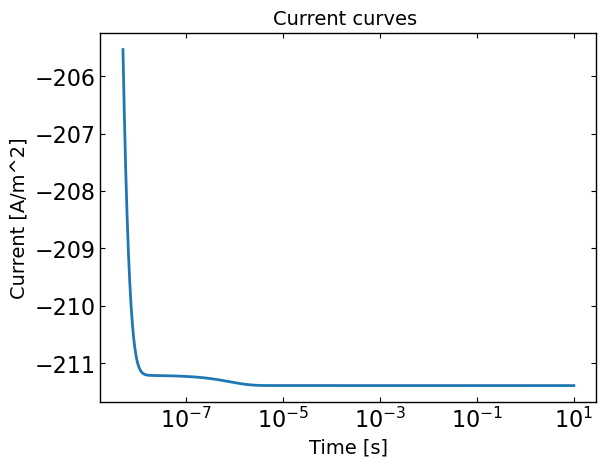

In [5]:
# Check for an appropriate time slice for Voc
# The tVG frequency range was from 1E-1Hz - 1E8Hz, 20 steps, with Delta V = 5mV
f_max = 1E8
f_min = 1E-1


# Lowest desired lifetime
tau_min = 1/f_max 
tau_max = 1/f_min

sample_index = 9

sample = random_samples[sample_index]
print(sample["sample_id"])
time = sample["tj_0V_L"]["t"].values
current = sample["tj_0V_L"]["Jext"].values

# Set time based on the maximum observable time window
start_time = 1/(2*f_max)
print(start_time)

# Clean up the current
filter = np.where(time > start_time)
current = current[filter]
time = time[filter]

plt.plot(time, current)
plt.xscale("log")
plt.ylabel("Current [A/m^2]")
plt.xlabel("Time [s]")
plt.title("Current curves ")

In [6]:
drt_fits = drt.checkerboard_fit(time, current)

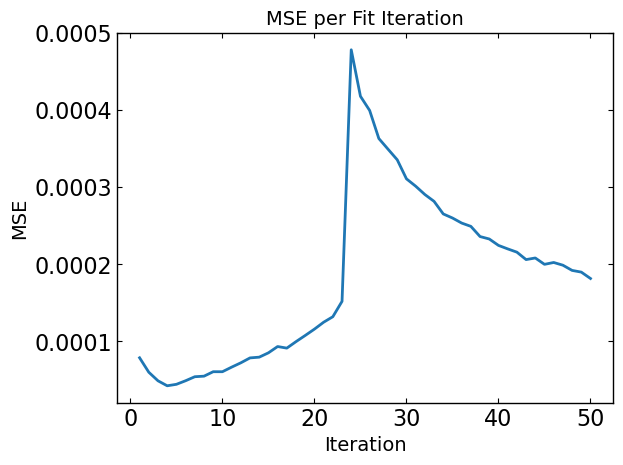

In [7]:
drt.plot_MSE(drt_fits)

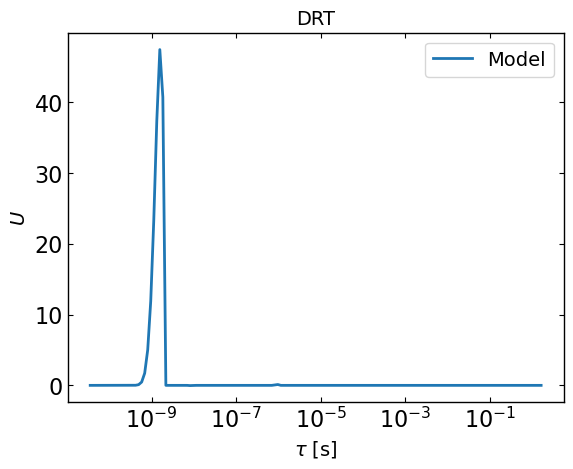

In [8]:
drt_fits[0].plot_U()

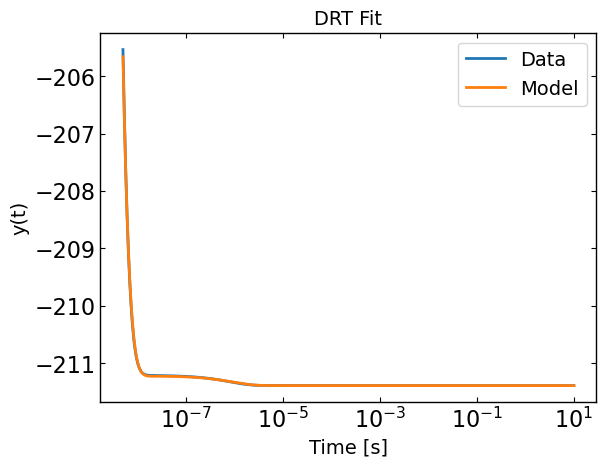

In [9]:
drt_fits[0].plot_y_model(time, current)

1193


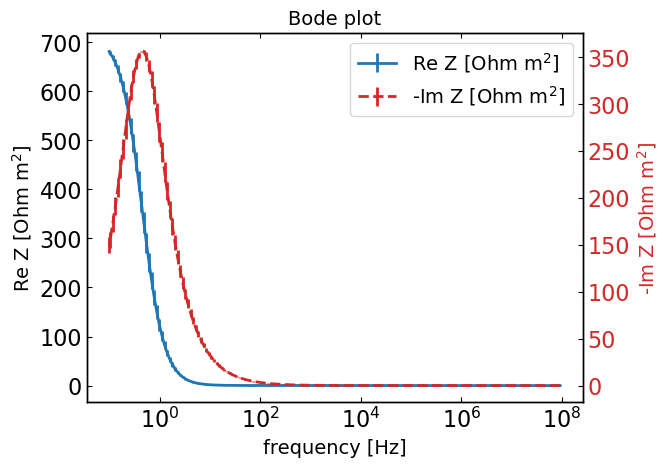

In [10]:
file_path = f"freqZ_0V_L_{sample["sample_id"]}.dat"
print(sample["sample_id"])
Bode_plot(data_directory_path, file_path)

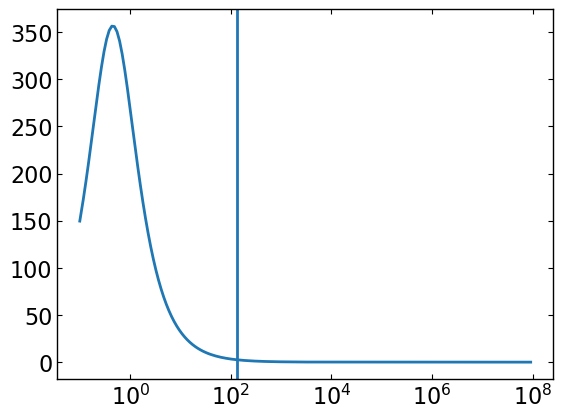

In [11]:
# Find the peak frequency here 
from scipy.signal import find_peaks
find_peaks(-1*sample['freqZ_0V_L']["ImZ"].values, )
plt.plot(sample['freqZ_0V_L']['freq'].values, -1*sample['freqZ_0V_L']['ImZ'].values)
plt.axvline(130)
plt.xscale('log')

In [84]:
(-1*sample['freqZ_0V_L']["ImZ"]).argmax()

np.int64(161)

Above, I'm struggling to make sense of the difference in peak positions. I do not understand how the Impedance spectrum is giving a peak at 10^0 Hz while the IS isn't picking up anythin at that end. 

## Setting a better tau range for U objects 
After chatting with Jan Anton, we only really want to display DRT curve lifetimes that correspond to the inverse of passed frequencies for IS experiments. 

Generally, DRT will fit better the further away from the start time it is so the system can relax a little more. Consequently, we want to pick a start time that's as far from the initial system start time as possible. 

In [12]:
# Parameters used to generate the tVG.dat file 
f_min = 1E-1 
f_max = 1E8
f_step = 20

ini_timeFactor = 1E-3
timeFactor = 1.02

# This is far too close to the pulse
first_time_step = ini_timeFactor/f_max

This proposed first time step is still far too close to the initial simulation time. Instead, we can try and use a windowed approach as follows: 

In [13]:
def get_latest_start_time(f_max: float, ini_timeFactor: float = 1E-3, timeFactor: float = 1.02, initial_time_value: float = 0, max_iters: int = 10000) -> float:
    """Get min time using the formula for time steps with increasing spacing used to generate the tVG file in impedance.py"""
    # Set up a time-step iterator 
    previous_time = initial_time_value
    initial_timestep = ini_timeFactor/f_max
    
    largest_permissable_timestep = 1/(2*f_max) # Coming straight from the Nyquist/Shanon sampling theorem
    
    # Iterate through timesteps until we pass the threshold, then return the discrete time value just before the threshold value
    i = 1
    while i >= 1 and i < max_iters:
        timestep = initial_timestep*(timeFactor)**i
        
        if timestep > largest_permissable_timestep:
            return previous_time 

        time = previous_time + timestep
        previous_time = time
        
        i += 1
        
    return 0.0
        

def get_earliest_end_time(f_min: float) -> float:
    earliest_end_time = 1/f_min
    return earliest_end_time


def get_start_and_end_times(f_min: float, f_max: float) -> tuple[float, float]:
    latest_start_time = get_latest_start_time(f_max)
    earliest_end_time = get_earliest_end_time(f_min)
    return latest_start_time, earliest_end_time

In [14]:
# Thus, if we want lifetimes equivalent to 1/1E8, we need to pass a time-slice that starts at the latest at 1E-6
get_latest_start_time(f_max=1E8)
get_earliest_end_time(f_min=1E-1)

10.0

This now gives us a way of finding the latest time we can take to still display lifetimes corresponding to the inverse of the max frequency put in by the user. We can try implementing this on one of the samples as before.

In [15]:
# Define some more helper functions to take a sample, trim time signal to appropriate values based on frequency, and return the current and frequency
import numpy.typing as npt
import enum

# Store the different experimental types in an ennumerator
class ExperimentType(str, enum.Enum):
    OPEN_CIRCUIT = "Voc",
    SHORT_CIRCUIT = "0V"


def get_signal_from_sample(sample: dict, f_min: float = 1E-1, f_max: float = 1E8, 
                           experiment_type: ExperimentType = ExperimentType.SHORT_CIRCUIT) -> tuple[npt.NDArray, npt.NDArray]:
    """Returns an output current for a sample within a window calculated from the start and end frequencies"""
    latest_start_time, earliest_end_time = get_start_and_end_times(f_min, f_max)

    tj_file_name = f"tj_{experiment_type.value}_L"
    
    time = sample[tj_file_name]["t"].values
    current = sample[tj_file_name]["Jext"].values

    # Clean up the signal with the found start and end times
    after_start_time = time >= latest_start_time
    before_end_time = time <= earliest_end_time
    filter = [after_start and before_end for after_start, before_end in zip(after_start_time, before_end_time)]
    current = current[filter]
    time = time[filter]
    
    return time, current
    

## Sample 1

In [16]:
sample_index = 0
sample = random_samples[sample_index]
experiment_type = ExperimentType.SHORT_CIRCUIT

In [22]:
# Trim current window to range specified by min and max frequencies used in IS
time, current = get_signal_from_sample(sample, f_min = 1E-1, f_max = 1E8, experiment_type=experiment_type)

# Run fits 
drt_fits_sample_1 = drt.checkerboard_fit(time, current, checkerboard_iters=100)

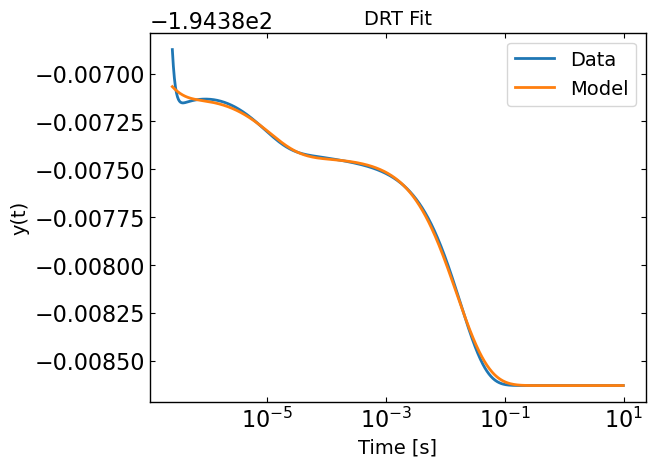

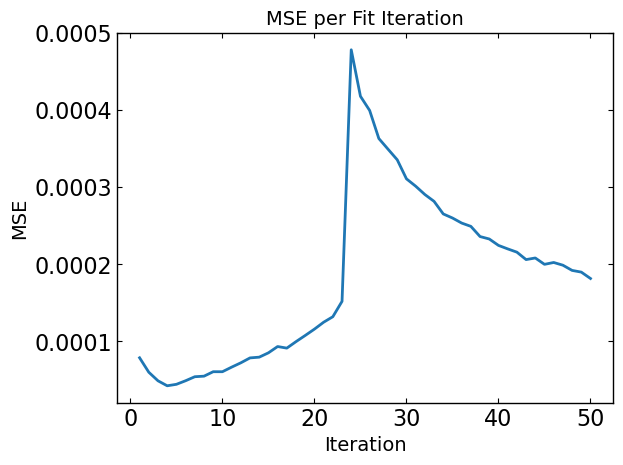

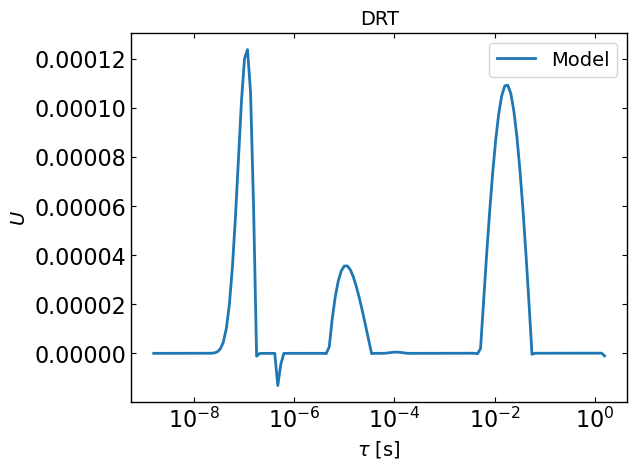

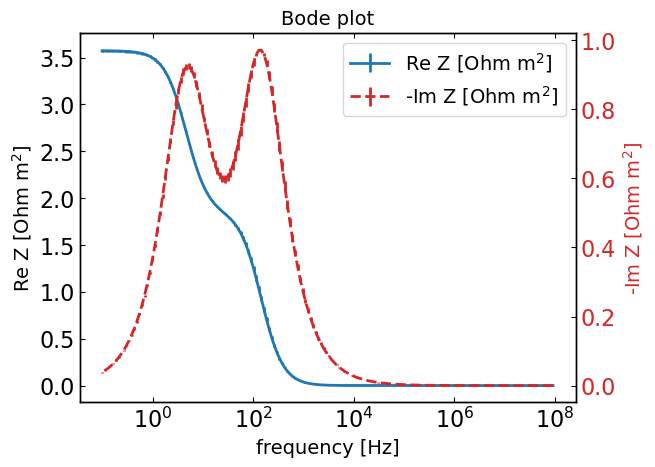

In [23]:
# Plots 
fit_index = 0
fit_sample_1 = drt_fits_sample_1[fit_index]

# DRT Plots 
plot_title = f"Sample {sample_index + 1}"
fit_sample_1.plot_y_model(time, current)
drt.plot_MSE(drt_fits)
fit_sample_1.plot_U()

# Bode Plots
file_path = f"freqZ_{experiment_type.value}_L_{sample["sample_id"]}.dat"
Bode_plot(data_directory_path, file_path)

## Sample 2

In [24]:
sample_index = 1
sample = random_samples[sample_index]
experiment_type = ExperimentType.SHORT_CIRCUIT

In [ ]:
# Trim current window to range specified by min and max frequencies used in IS
time, current = get_signal_from_sample(sample, f_min = 1E-1, f_max = 1E8)

# Run fits 
drt_fits_sample_2 = drt.checkerboard_fit(time, current, checkerboard_iters=100)
drt_fits_sample_2

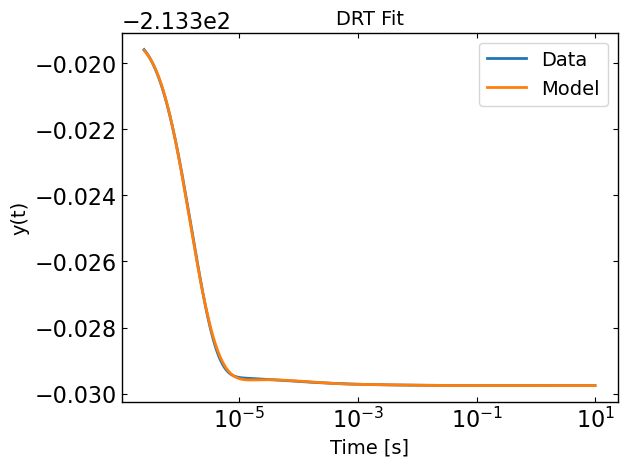

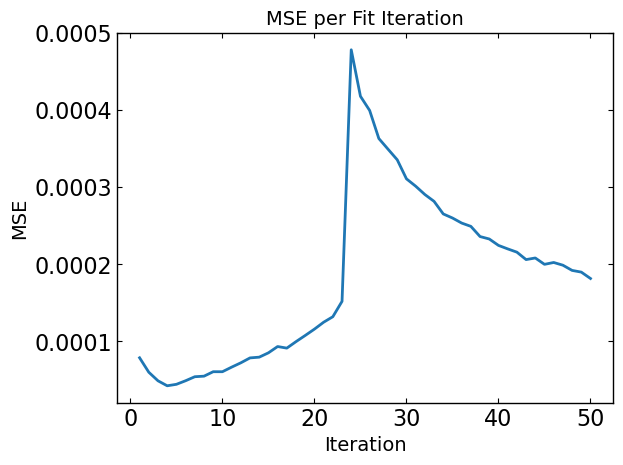

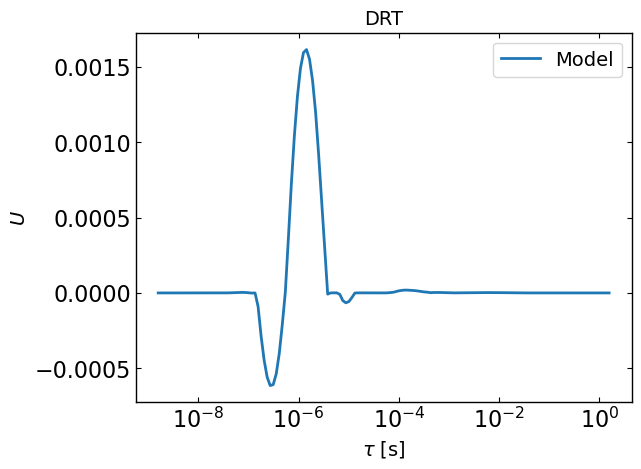

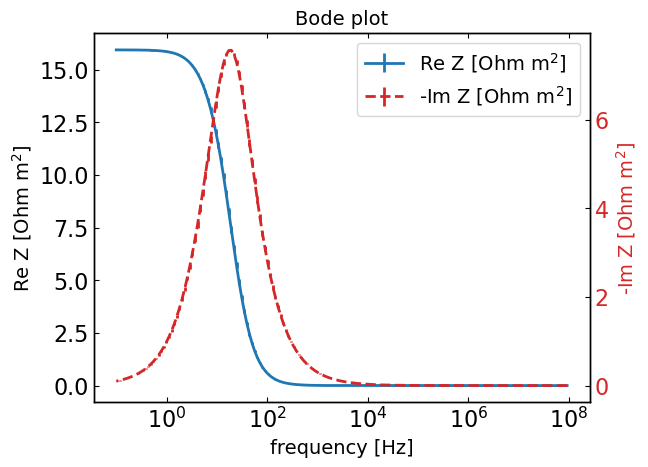

In [94]:
# Plots 
fit_index = -1
fit_sample_2 = drt_fits_sample_2[fit_index]

# Plots 
plot_title = f"Sample {sample_index + 1}"
fit_sample_2.plot_y_model(time, current)
drt.plot_MSE(drt_fits)
fit_sample_2.plot_U()

# Bode Plots
file_path = f"freqZ_{experiment_type.value}_L_{sample["sample_id"]}.dat"
Bode_plot(data_directory_path, file_path)

## Sample 3

In [95]:
sample_index = 2
sample = random_samples[sample_index]
experiment_type = ExperimentType.SHORT_CIRCUIT

In [96]:
# Trim current window to range specified by min and max frequencies used in IS
time, current = get_signal_from_sample(sample, f_min = 1E-1, f_max = 1E8)

# Run fits 
drt_fits_sample_3 = drt.checkerboard_fit(time, current, checkerboard_iters=100)

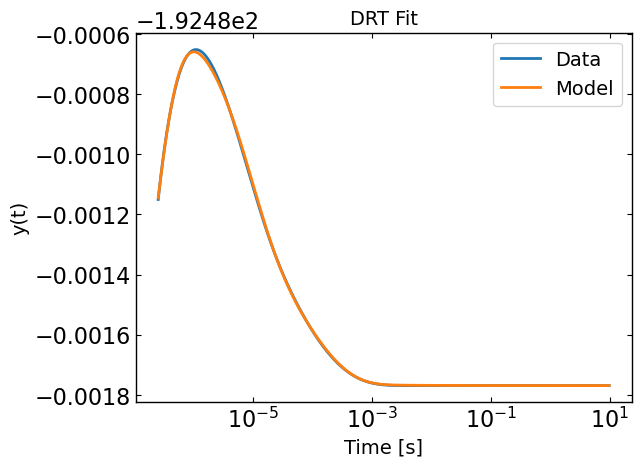

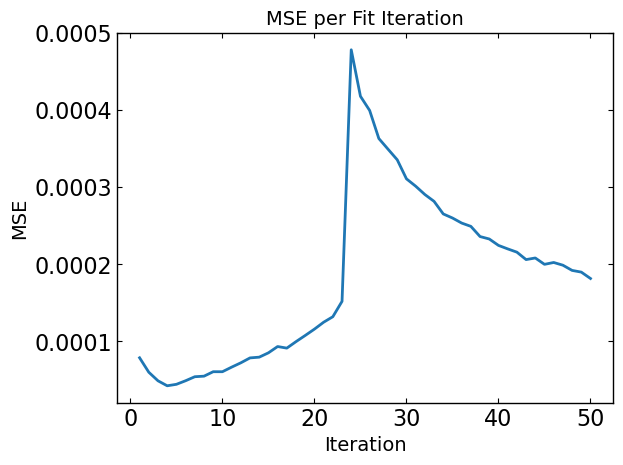

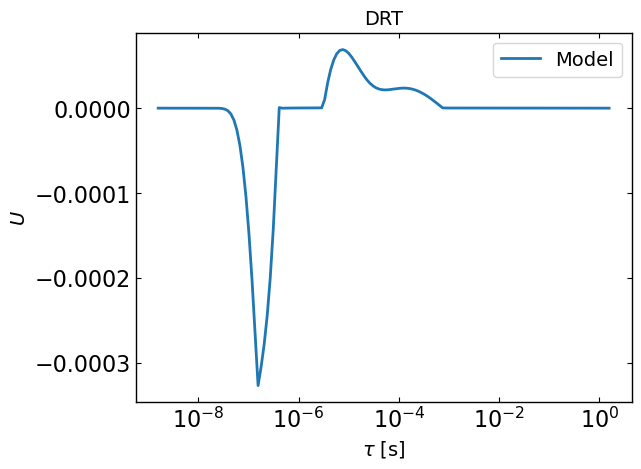

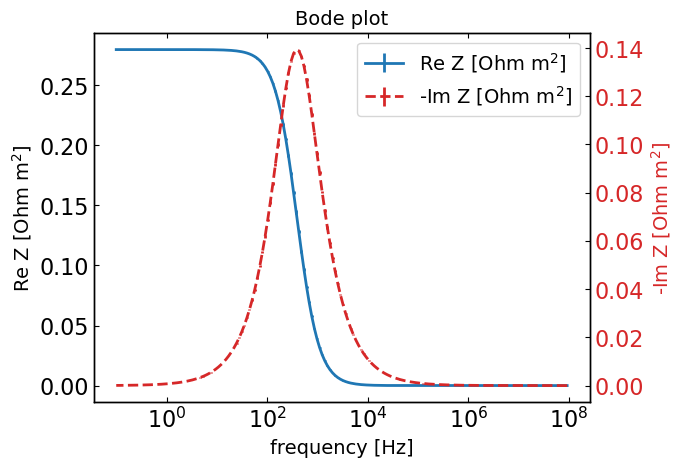

In [98]:
# Plots 
fit_index = 5
fit_sample_3 = drt_fits_sample_3[fit_index]

# Plots 
plot_title = f"Sample {sample_index + 1}"
fit_sample_3.plot_y_model(time, current)
drt.plot_MSE(drt_fits)
fit_sample_3.plot_U()

# Bode Plots
file_path = f"freqZ_{experiment_type.value}_L_{sample["sample_id"]}.dat"
Bode_plot(data_directory_path, file_path)